In [1]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

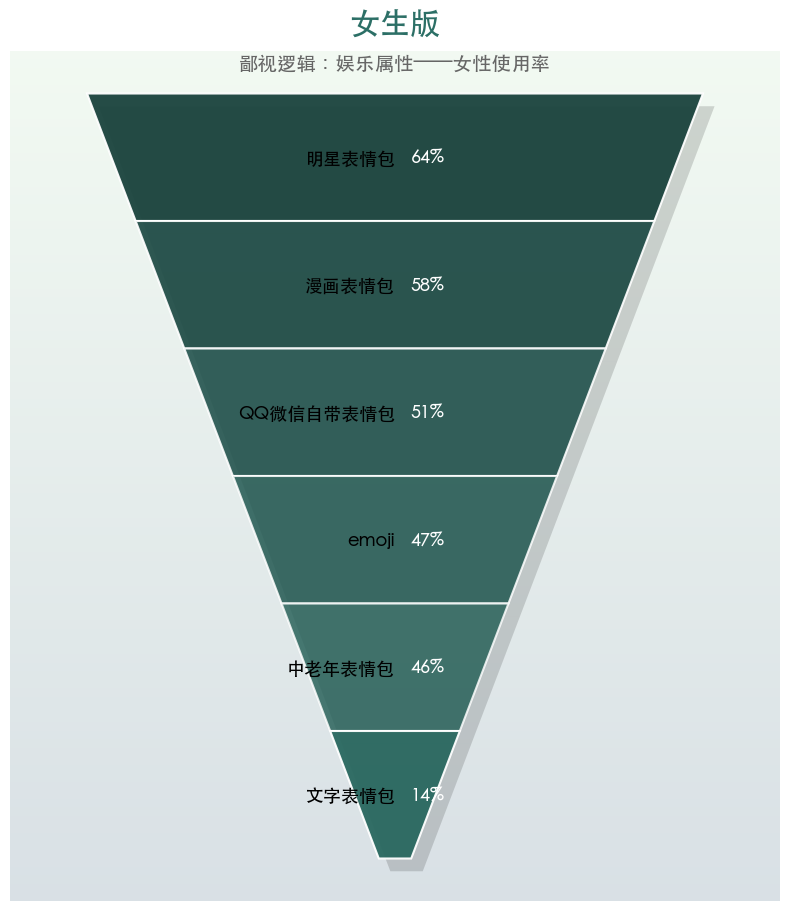

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np

# 标签和数据
labels = [
    "明星表情包", "漫画表情包", "QQ微信自带表情包",
    "emoji", "中老年表情包", "文字表情包"
]
values = [64, 58, 51, 47, 46, 14]

# 生成渐变色系
def get_gradient_colors(base_color, num_layers, lightness_range=(0.6, 1.0)):
    """生成从深到浅的渐变色"""
    from matplotlib.colors import LinearSegmentedColormap
    import matplotlib.colors as mcolors
    
    # 将十六进制颜色转换为RGB
    rgb = mcolors.hex2color(base_color)
    
    # 创建渐变色映射
    cmap = LinearSegmentedColormap.from_list(
        f'custom_{base_color}', 
        [(rgb[0]*lightness_range[0], rgb[1]*lightness_range[0], rgb[2]*lightness_range[0]), 
         (rgb[0]*lightness_range[1], rgb[1]*lightness_range[1], rgb[2]*lightness_range[1])]
    )
    
    return [cmap(i/num_layers) for i in range(num_layers)]

# 使用绿色系作为基础
base_color = '#2c6f66'
colors = get_gradient_colors(base_color, len(labels))

# 图形参数
num_layers = len(labels)
fig, ax = plt.subplots(figsize=(8, 10))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# 底部顶点坐标
bottom_x = 0.5
bottom_y = 0.05

# 顶部宽度（整个倒三角上边）
top_left = (0.1, 0.95)
top_right = (0.9, 0.95)

# 每层高度（均分）
layer_height = (top_left[1] - bottom_y) / num_layers

# 绘制背景渐变
gradient_bg = np.zeros((100, 100, 3))
for i in range(100):
    for j in range(100):
        y_norm = i / 100
        # 背景色从浅绿到更浅的绿
        gradient_bg[i, j] = [0.95 - y_norm*0.1, 0.98 - y_norm*0.1, 0.95 - y_norm*0.05]
ax.imshow(gradient_bg, extent=[0, 1, 0, 1], aspect='auto', zorder=0)

# 添加阴影效果
shadow_offset = 0.015
for i in range(num_layers):
    # 顶部 y 和 底部 y
    y_top = top_left[1] - i * layer_height
    y_bottom = top_left[1] - (i + 1) * layer_height

    # 计算对应高度下三角左右边界的 x 坐标
    x_left_top = top_left[0] + (bottom_x - top_left[0]) * (top_left[1] - y_top) / top_left[1]
    x_right_top = top_right[0] - (top_right[0] - bottom_x) * (top_right[1] - y_top) / top_right[1]
    x_left_bottom = top_left[0] + (bottom_x - top_left[0]) * (top_left[1] - y_bottom) / top_left[1]
    x_right_bottom = top_right[0] - (top_right[0] - bottom_x) * (top_right[1] - y_bottom) / top_right[1]

    # 构造阴影形状
    shadow_points = [
        (x_left_top + shadow_offset, y_top - shadow_offset),
        (x_right_top + shadow_offset, y_top - shadow_offset),
        (x_right_bottom + shadow_offset, y_bottom - shadow_offset),
        (x_left_bottom + shadow_offset, y_bottom - shadow_offset)
    ]
    shadow = Polygon(shadow_points, closed=True, facecolor='black', alpha=0.15, zorder=i+1)
    ax.add_patch(shadow)

# 绘制主图表
for i in range(num_layers):
    # 顶部 y 和 底部 y
    y_top = top_left[1] - i * layer_height
    y_bottom = top_left[1] - (i + 1) * layer_height

    # 计算对应高度下三角左右边界的 x 坐标
    x_left_top = top_left[0] + (bottom_x - top_left[0]) * (top_left[1] - y_top) / top_left[1]
    x_right_top = top_right[0] - (top_right[0] - bottom_x) * (top_right[1] - y_top) / top_right[1]
    x_left_bottom = top_left[0] + (bottom_x - top_left[0]) * (top_left[1] - y_bottom) / top_left[1]
    x_right_bottom = top_right[0] - (top_right[0] - bottom_x) * (top_right[1] - y_bottom) / top_right[1]

    # 构造梯形/三角带形状
    points = [
        (x_left_top, y_top),
        (x_right_top, y_top),
        (x_right_bottom, y_bottom),
        (x_left_bottom, y_bottom)
    ]
    
    # 添加轻微的透明度变化，使底部更明显
    alpha = 0.95 - i * 0.03 if i < num_layers - 1 else 0.95
    tri = Polygon(points, closed=True, facecolor=colors[i], edgecolor='white', linewidth=1.5, alpha=alpha, zorder=i+2)
    ax.add_patch(tri)

    # 在每层中间写文字
    y_text = (y_top + y_bottom) / 2
    ax.text(0.5, y_text, f"{labels[i]}", 
            color='black', ha='right', va='center', fontsize=13, fontweight='medium',
            transform=ax.transAxes, zorder=10)
    
    # 添加百分比标签
    ax.text(0.52, y_text, f"{values[i]}%", 
            color='white', ha='left', va='center', fontsize=13, fontweight='bold',
            transform=ax.transAxes, zorder=10)

# 添加新的标题相关文字，按照需求调整标题、副标题内容
plt.text(0.5, 1.02, "女生版", ha='center', fontsize=22, weight='bold', color=base_color, transform=ax.transAxes)
plt.text(0.5, 0.98, "鄙视逻辑：娱乐属性——女性使用率", ha='center', fontsize=14, color='#666666', transform=ax.transAxes)

# 调整布局
plt.tight_layout()
plt.subplots_adjust(top=0.9, bottom=0.05)
plt.show()

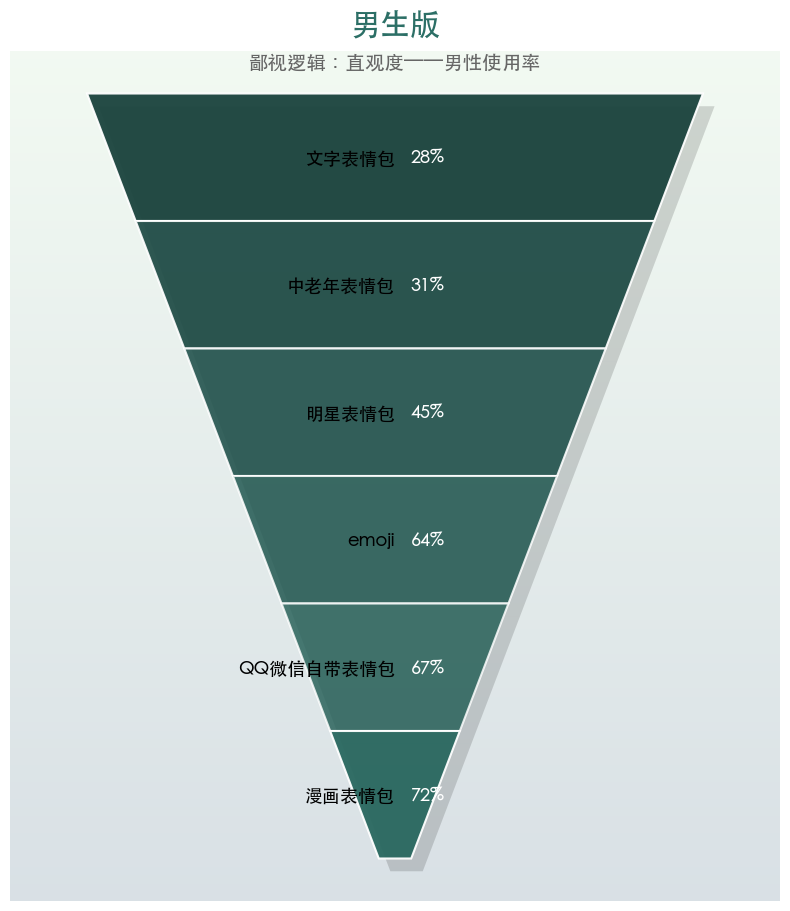

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np

# 标签和数据（对应男生版 鄙视逻辑：直观度——男性使用率 数据）
labels = [
    "文字表情包", "中老年表情包", "明星表情包", 
    "emoji", "QQ微信自带表情包", "漫画表情包"
]
values = [28, 31, 45, 64, 67, 72]

# 生成渐变色系
def get_gradient_colors(base_color, num_layers, lightness_range=(0.6, 1.0)):
    """生成从深到浅的渐变色"""
    from matplotlib.colors import LinearSegmentedColormap
    import matplotlib.colors as mcolors
    
    # 将十六进制颜色转换为RGB
    rgb = mcolors.hex2color(base_color)
    
    # 创建渐变色映射
    cmap = LinearSegmentedColormap.from_list(
        f'custom_{base_color}', 
        [(rgb[0]*lightness_range[0], rgb[1]*lightness_range[0], rgb[2]*lightness_range[0]), 
         (rgb[0]*lightness_range[1], rgb[1]*lightness_range[1], rgb[2]*lightness_range[1])]
    )
    
    return [cmap(i/num_layers) for i in range(num_layers)]

# 使用绿色系作为基础
base_color = '#2c6f66'
colors = get_gradient_colors(base_color, len(labels))

# 图形参数
num_layers = len(labels)
fig, ax = plt.subplots(figsize=(8, 10))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# 底部顶点坐标
bottom_x = 0.5
bottom_y = 0.05

# 顶部宽度（整个倒三角上边）
top_left = (0.1, 0.95)
top_right = (0.9, 0.95)

# 每层高度（均分）
layer_height = (top_left[1] - bottom_y) / num_layers

# 绘制背景渐变
gradient_bg = np.zeros((100, 100, 3))
for i in range(100):
    for j in range(100):
        y_norm = i / 100
        # 背景色从浅绿到更浅的绿
        gradient_bg[i, j] = [0.95 - y_norm*0.1, 0.98 - y_norm*0.1, 0.95 - y_norm*0.05]
ax.imshow(gradient_bg, extent=[0, 1, 0, 1], aspect='auto', zorder=0)

# 添加阴影效果
shadow_offset = 0.015
for i in range(num_layers):
    # 顶部 y 和 底部 y
    y_top = top_left[1] - i * layer_height
    y_bottom = top_left[1] - (i + 1) * layer_height

    # 计算对应高度下三角左右边界的 x 坐标
    x_left_top = top_left[0] + (bottom_x - top_left[0]) * (top_left[1] - y_top) / top_left[1]
    x_right_top = top_right[0] - (top_right[0] - bottom_x) * (top_right[1] - y_top) / top_right[1]
    x_left_bottom = top_left[0] + (bottom_x - top_left[0]) * (top_left[1] - y_bottom) / top_left[1]
    x_right_bottom = top_right[0] - (top_right[0] - bottom_x) * (top_right[1] - y_bottom) / top_right[1]

    # 构造阴影形状
    shadow_points = [
        (x_left_top + shadow_offset, y_top - shadow_offset),
        (x_right_top + shadow_offset, y_top - shadow_offset),
        (x_right_bottom + shadow_offset, y_bottom - shadow_offset),
        (x_left_bottom + shadow_offset, y_bottom - shadow_offset)
    ]
    shadow = Polygon(shadow_points, closed=True, facecolor='black', alpha=0.15, zorder=i+1)
    ax.add_patch(shadow)

# 绘制主图表
for i in range(num_layers):
    # 顶部 y 和 底部 y
    y_top = top_left[1] - i * layer_height
    y_bottom = top_left[1] - (i + 1) * layer_height

    # 计算对应高度下三角左右边界的 x 坐标
    x_left_top = top_left[0] + (bottom_x - top_left[0]) * (top_left[1] - y_top) / top_left[1]
    x_right_top = top_right[0] - (top_right[0] - bottom_x) * (top_right[1] - y_top) / top_right[1]
    x_left_bottom = top_left[0] + (bottom_x - top_left[0]) * (top_left[1] - y_bottom) / top_left[1]
    x_right_bottom = top_right[0] - (top_right[0] - bottom_x) * (top_right[1] - y_bottom) / top_right[1]

    # 构造梯形/三角带形状
    points = [
        (x_left_top, y_top),
        (x_right_top, y_top),
        (x_right_bottom, y_bottom),
        (x_left_bottom, y_bottom)
    ]
    
    # 添加轻微的透明度变化，使底部更明显
    alpha = 0.95 - i * 0.03 if i < num_layers - 1 else 0.95
    tri = Polygon(points, closed=True, facecolor=colors[i], edgecolor='white', linewidth=1.5, alpha=alpha, zorder=i+2)
    ax.add_patch(tri)

    # 在每层中间写文字
    y_text = (y_top + y_bottom) / 2
    ax.text(0.5, y_text, f"{labels[i]}", 
            color='black', ha='right', va='center', fontsize=13, fontweight='medium',
            transform=ax.transAxes, zorder=10)
    
    # 添加百分比标签
    ax.text(0.52, y_text, f"{values[i]}%", 
            color='white', ha='left', va='center', fontsize=13, fontweight='bold',
            transform=ax.transAxes, zorder=10)

# 添加新的标题相关文字，按照男生版需求调整标题、副标题内容
plt.text(0.5, 1.02, "男生版", ha='center', fontsize=22, weight='bold', color=base_color, transform=ax.transAxes)
plt.text(0.5, 0.98, "鄙视逻辑：直观度——男性使用率", ha='center', fontsize=14, color='#666666', transform=ax.transAxes)

# 调整布局
plt.tight_layout()
plt.subplots_adjust(top=0.9, bottom=0.05)
plt.show()

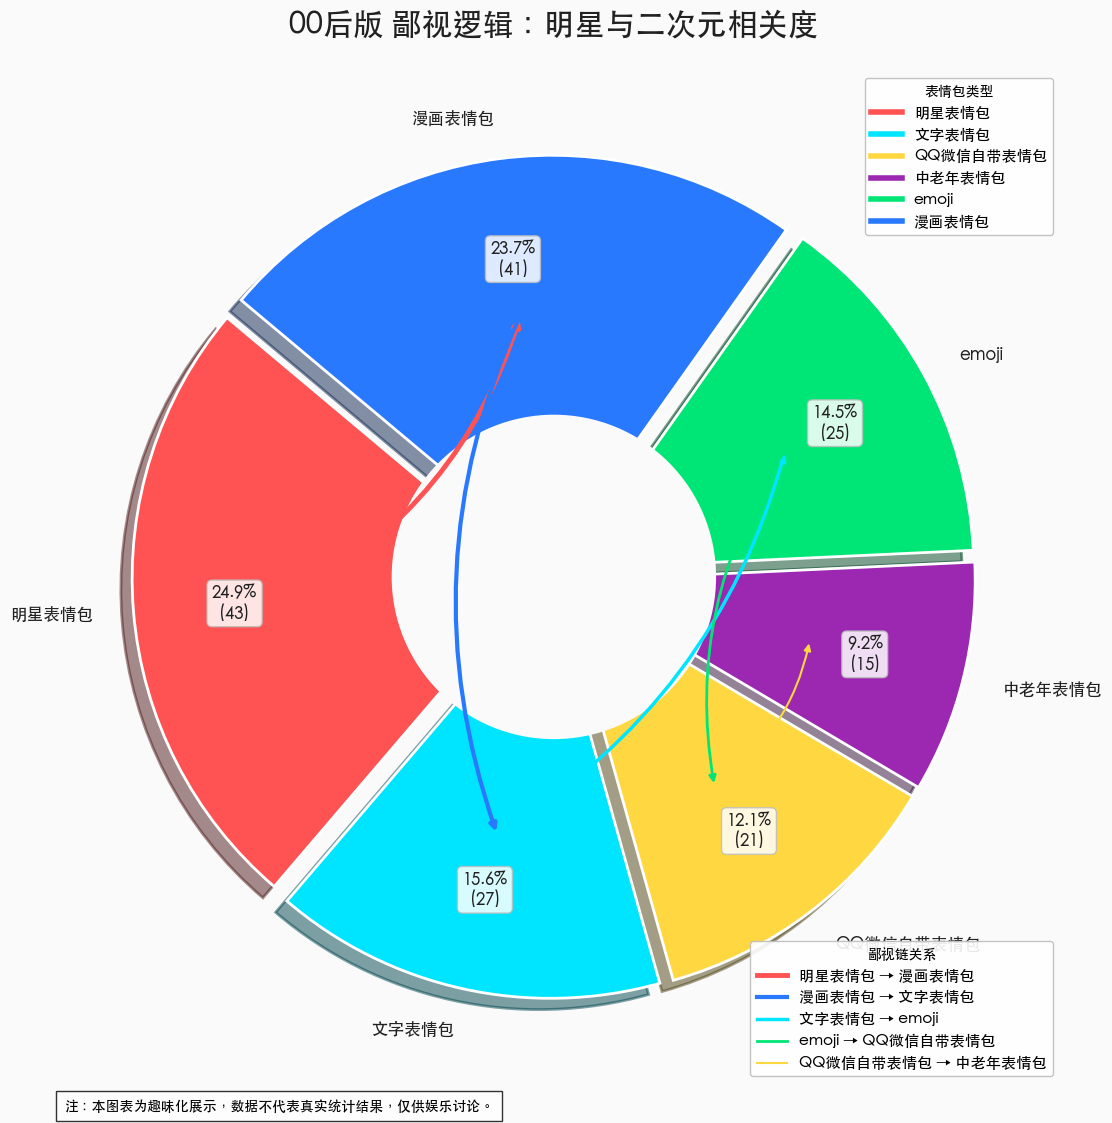

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# 表情包配色方案（严格对应类型）
color_map = {
    '明星表情包': '#FF5252',
    '文字表情包': '#00E5FF',
    'QQ微信自带表情包': '#FFD740',
    '中老年表情包': '#9C27B0',
    'emoji': '#00E676',
    '漫画表情包': '#2979FF',
}

# 数据定义（保持原逻辑）
categories = ['明星表情包', '文字表情包', 'QQ微信自带表情包', 
              '中老年表情包', 'emoji', '漫画表情包']
percentages = [43, 27, 21, 16, 25, 41]

# 鄙视链关系（明确类型对应，方便颜色映射）
connections = [
    ('明星表情包', '漫画表情包', 3.5),   # 明星 → 漫画
    ('漫画表情包', '文字表情包', 3),    # 漫画 → 文字
    ('文字表情包', 'emoji', 2.5),       # 文字 → emoji
    ('emoji', 'QQ微信自带表情包', 2),    # emoji → QQ
    ('QQ微信自带表情包', '中老年表情包', 1.5),  # QQ → 中老年
]

# 创建画布与基础设置
fig, ax = plt.subplots(figsize=(14, 12), facecolor='#FAFAFA')
ax.set_facecolor('#FAFAFA')
ax.grid(True, linestyle='--', alpha=0.3, color='#EEEEEE')

# 绘制饼图（强化阴影与边框）
wedges, texts, autotexts = ax.pie(
    percentages, 
    labels=categories, 
    autopct=lambda p: f'{p:.1f}%\n({int(p * sum(percentages) / 100)})',
    colors=[color_map[c] for c in categories],
    startangle=140,
    pctdistance=0.75,
    explode=[0.04] * 6,
    shadow=True,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'antialiased': True},
    textprops={'fontsize': 12, 'weight': 'bold', 'color': '#212121'}
)

# 中心白色遮罩（增强层次感）
center_circle = plt.Circle((0, 0), 0.4, color='#FAFAFA', linewidth=0, zorder=1)
ax.add_artist(center_circle)

# 优化百分比标签样式（带白色背景框）
for a in autotexts:
    a.set_bbox(dict(boxstyle="round,pad=0.3", fc="white", ec="#BDBDBD", alpha=0.85))

# 设置标题
ax.set_title('00后版 鄙视逻辑：明星与二次元相关度', 
             fontsize=22, 
             fontweight='bold', 
             color='#212121',
             pad=25)

# 绘制鄙视链箭头（颜色严格对应表情包主色）
for start_cat, end_cat, weight in connections:
    # 找到对应扇区的角度
    start_wedge = [w for w, l in zip(wedges, categories) if l == start_cat][0]
    end_wedge = [w for w, l in zip(wedges, categories) if l == end_cat][0]
    
    start_angle = (start_wedge.theta2 + start_wedge.theta1) / 2
    end_angle = (end_wedge.theta2 + end_wedge.theta1) / 2
    
    # 计算坐标（统一半径，避免混乱）
    radius = 0.65
    start_x = np.cos(np.radians(start_angle)) * radius
    start_y = np.sin(np.radians(start_angle)) * radius
    end_x = np.cos(np.radians(end_angle)) * radius
    end_y = np.sin(np.radians(end_angle)) * radius
    
    # 绘制箭头（单色，与起始表情包颜色一致）
    ax.annotate(
        '', 
        xy=(end_x, end_y), 
        xytext=(start_x, start_y),
        arrowprops=dict(
            arrowstyle='-|>', 
            color=color_map[start_cat],  # 用起始类型的颜色
            lw=weight,
            connectionstyle="arc3,rad=0.2"
        )
    )

# 构建图例（分两组：类型 + 关系）
legend_type = [
    Line2D([0], [0], color=color_map[c], lw=4, label=c) 
    for c in categories
]

legend_arrow = [
    Line2D([0], [0], color=color_map[start], lw=weight, label=f'{start} → {end}') 
    for start, end, weight in connections
]

# 合并图例（先类型，后关系）
legend1 = ax.legend(
    handles=legend_type, 
    loc='upper right', 
    title="表情包类型", 
    fontsize=11, 
    frameon=True,
    framealpha=0.9, 
    facecolor='white', 
    edgecolor='#BDBDBD'
)
ax.add_artist(legend1)

ax.legend(
    handles=legend_arrow, 
    loc='lower right', 
    title="鄙视链关系", 
    fontsize=11, 
    frameon=True,
    framealpha=0.9, 
    facecolor='white', 
    edgecolor='#BDBDBD'
)

# 底部注释
plt.figtext(
    0.15, 0.02, 
    "注：本图表为趣味化展示，数据不代表真实统计结果，仅供娱乐讨论。", 
    ha="left", 
    fontsize=10, 
    bbox={"facecolor":"white", "alpha":0.8, "pad":6}
)

# 调整布局
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

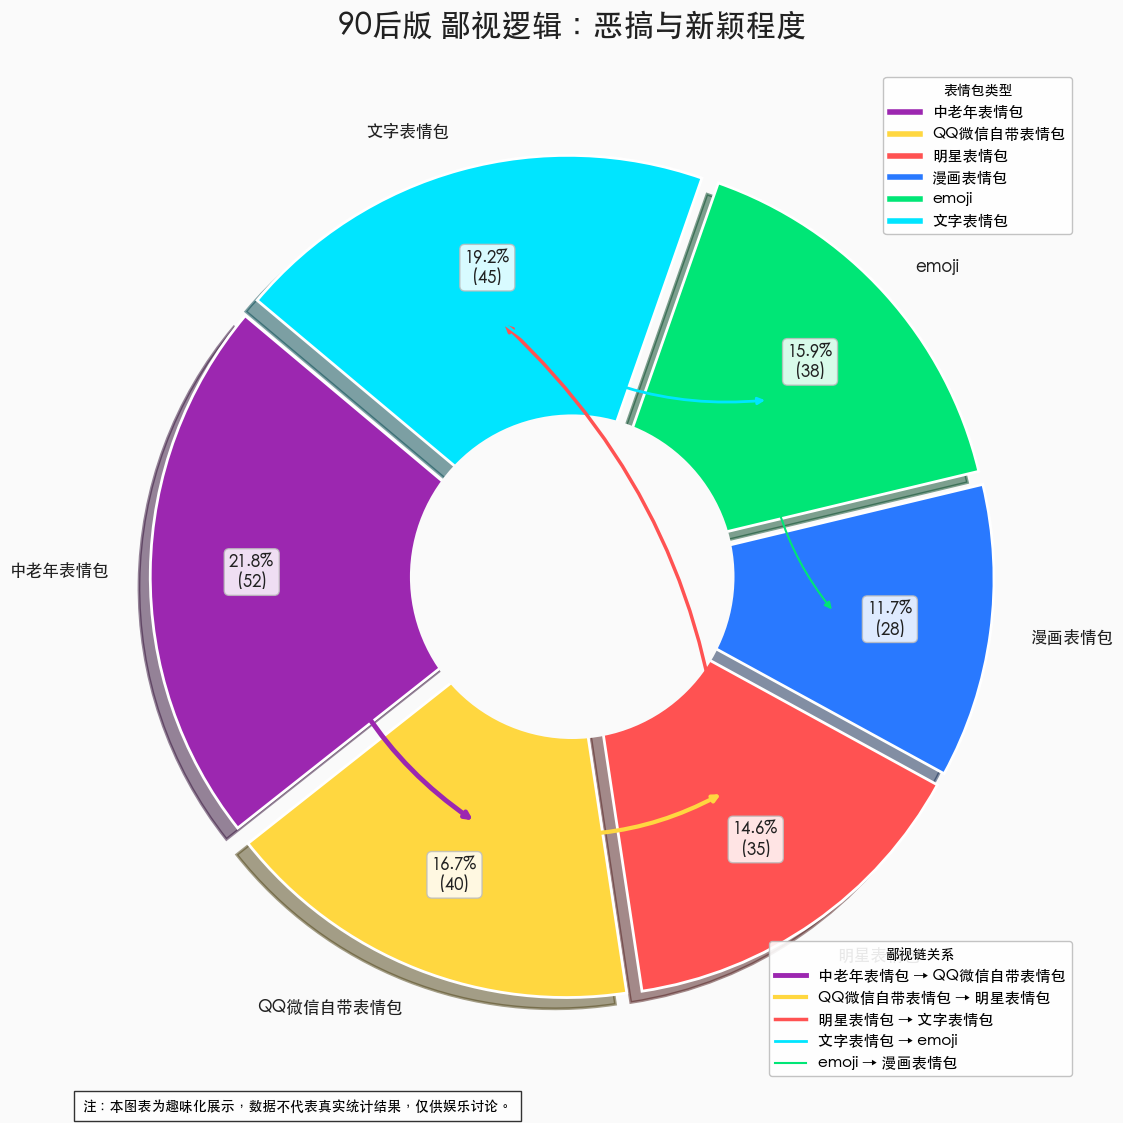

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# 表情包配色方案（严格对应类型）
color_map = {
    '明星表情包': '#FF5252',
    '文字表情包': '#00E5FF',
    'QQ微信自带表情包': '#FFD740',
    '中老年表情包': '#9C27B0',
    'emoji': '#00E676',
    '漫画表情包': '#2979FF',
}

# 数据定义（保持原逻辑）
categories = ['中老年表情包', 'QQ微信自带表情包', '明星表情包', 
              '漫画表情包', 'emoji', '文字表情包']
percentages = [52, 40, 35, 28, 38, 46]

# 鄙视链关系（明确类型对应，方便颜色映射）
connections = [
    ('中老年表情包', 'QQ微信自带表情包', 3.5),   # 中老年 → QQ微信
    ('QQ微信自带表情包', '明星表情包', 3),    # QQ微信 → 明星
    ('明星表情包', '文字表情包', 2.5),       # 明星 → 文字
    ('文字表情包', 'emoji', 2),    # 文字 → emoji
    ('emoji', '漫画表情包', 1.5),  # emoji → 漫画
]

# 创建画布与基础设置
fig, ax = plt.subplots(figsize=(14, 12), facecolor='#FAFAFA')
ax.set_facecolor('#FAFAFA')
ax.grid(True, linestyle='--', alpha=0.3, color='#EEEEEE')

# 绘制饼图（强化阴影与边框）
wedges, texts, autotexts = ax.pie(
    percentages, 
    labels=categories, 
    autopct=lambda p: f'{p:.1f}%\n({int(p * sum(percentages) / 100)})',
    colors=[color_map[c] for c in categories],
    startangle=140,
    pctdistance=0.75,
    explode=[0.04] * 6,
    shadow=True,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'antialiased': True},
    textprops={'fontsize': 12, 'weight': 'bold', 'color': '#212121'}
)

# 中心白色遮罩（增强层次感）
center_circle = plt.Circle((0, 0), 0.4, color='#FAFAFA', linewidth=0, zorder=1)
ax.add_artist(center_circle)

# 优化百分比标签样式（带白色背景框）
for a in autotexts:
    a.set_bbox(dict(boxstyle="round,pad=0.3", fc="white", ec="#BDBDBD", alpha=0.85))

# 设置标题
ax.set_title('90后版 鄙视逻辑：恶搞与新颖程度', 
             fontsize=22, 
             fontweight='bold', 
             color='#212121',
             pad=25)

# 绘制鄙视链箭头（颜色严格对应表情包主色）
for start_cat, end_cat, weight in connections:
    # 找到对应扇区的角度
    start_wedge = [w for w, l in zip(wedges, categories) if l == start_cat][0]
    end_wedge = [w for w, l in zip(wedges, categories) if l == end_cat][0]
    
    start_angle = (start_wedge.theta2 + start_wedge.theta1) / 2
    end_angle = (end_wedge.theta2 + end_wedge.theta1) / 2
    
    # 计算坐标（统一半径，避免混乱）
    radius = 0.65
    start_x = np.cos(np.radians(start_angle)) * radius
    start_y = np.sin(np.radians(start_angle)) * radius
    end_x = np.cos(np.radians(end_angle)) * radius
    end_y = np.sin(np.radians(end_angle)) * radius
    
    # 绘制箭头（单色，与起始表情包颜色一致）
    ax.annotate(
        '', 
        xy=(end_x, end_y), 
        xytext=(start_x, start_y),
        arrowprops=dict(
            arrowstyle='-|>', 
            color=color_map[start_cat],  # 用起始类型的颜色
            lw=weight,
            connectionstyle="arc3,rad=0.2"
        )
    )

# 构建图例（分两组：类型 + 关系）
legend_type = [
    Line2D([0], [0], color=color_map[c], lw=4, label=c) 
    for c in categories
]

legend_arrow = [
    Line2D([0], [0], color=color_map[start], lw=weight, label=f'{start} → {end}') 
    for start, end, weight in connections
]

# 合并图例（先类型，后关系）
legend1 = ax.legend(
    handles=legend_type, 
    loc='upper right', 
    title="表情包类型", 
    fontsize=11, 
    frameon=True,
    framealpha=0.9, 
    facecolor='white', 
    edgecolor='#BDBDBD'
)
ax.add_artist(legend1)

ax.legend(
    handles=legend_arrow, 
    loc='lower right', 
    title="鄙视链关系", 
    fontsize=11, 
    frameon=True,
    framealpha=0.9, 
    facecolor='white', 
    edgecolor='#BDBDBD'
)

# 底部注释
plt.figtext(
    0.15, 0.02, 
    "注：本图表为趣味化展示，数据不代表真实统计结果，仅供娱乐讨论。", 
    ha="left", 
    fontsize=10, 
    bbox={"facecolor":"white", "alpha":0.8, "pad":6}
)

# 调整布局
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

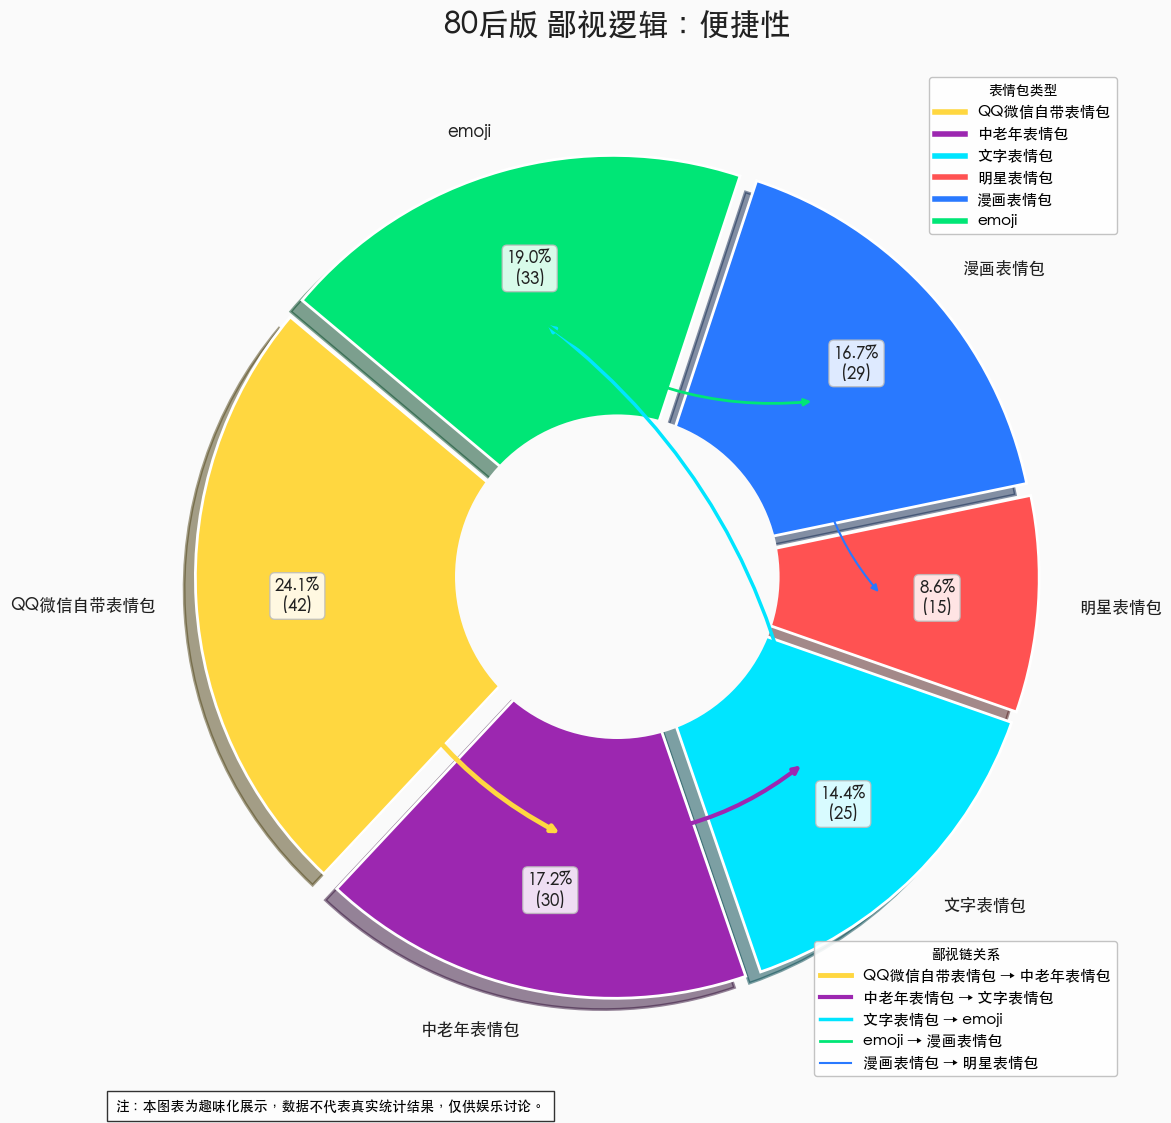

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# 表情包配色方案（严格对应类型）
color_map = {
    '明星表情包': '#FF5252',
    '文字表情包': '#00E5FF',
    'QQ微信自带表情包': '#FFD740',
    '中老年表情包': '#9C27B0',
    'emoji': '#00E676',
    '漫画表情包': '#2979FF',
}

# 数据定义（保持原逻辑）
categories = ['QQ微信自带表情包', '中老年表情包', '文字表情包', 
              '明星表情包', '漫画表情包', 'emoji']
percentages = [42, 30, 25, 15, 29, 33]

# 鄙视链关系（明确类型对应，方便颜色映射）
connections = [
    ('QQ微信自带表情包', '中老年表情包', 3.5),  # QQ微信 → 中老年
    ('中老年表情包', '文字表情包', 3),       # 中老年 → 文字
    ('文字表情包', 'emoji', 2.5),           # 文字 → emoji
    ('emoji', '漫画表情包', 2),            # emoji → 漫画
    ('漫画表情包', '明星表情包', 1.5),        # 漫画 → 明星
]

# 创建画布与基础设置
fig, ax = plt.subplots(figsize=(14, 12), facecolor='#FAFAFA')
ax.set_facecolor('#FAFAFA')
ax.grid(True, linestyle='--', alpha=0.3, color='#EEEEEE')

# 绘制饼图（强化阴影与边框）
wedges, texts, autotexts = ax.pie(
    percentages, 
    labels=categories, 
    autopct=lambda p: f'{p:.1f}%\n({int(p * sum(percentages) / 100)})',
    colors=[color_map[c] for c in categories],
    startangle=140,
    pctdistance=0.75,
    explode=[0.04] * 6,
    shadow=True,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'antialiased': True},
    textprops={'fontsize': 12, 'weight': 'bold', 'color': '#212121'}
)

# 中心白色遮罩（增强层次感）
center_circle = plt.Circle((0, 0), 0.4, color='#FAFAFA', linewidth=0, zorder=1)
ax.add_artist(center_circle)

# 优化百分比标签样式（带白色背景框）
for a in autotexts:
    a.set_bbox(dict(boxstyle="round,pad=0.3", fc="white", ec="#BDBDBD", alpha=0.85))

# 设置标题
ax.set_title('80后版 鄙视逻辑：便捷性', 
             fontsize=22, 
             fontweight='bold', 
             color='#212121',
             pad=25)

# 绘制鄙视链箭头（颜色严格对应表情包主色）
for start_cat, end_cat, weight in connections:
    # 找到对应扇区的角度
    start_wedge = [w for w, l in zip(wedges, categories) if l == start_cat][0]
    end_wedge = [w for w, l in zip(wedges, categories) if l == end_cat][0]
    
    start_angle = (start_wedge.theta2 + start_wedge.theta1) / 2
    end_angle = (end_wedge.theta2 + end_wedge.theta1) / 2
    
    # 计算坐标（统一半径，避免混乱）
    radius = 0.65
    start_x = np.cos(np.radians(start_angle)) * radius
    start_y = np.sin(np.radians(start_angle)) * radius
    end_x = np.cos(np.radians(end_angle)) * radius
    end_y = np.sin(np.radians(end_angle)) * radius
    
    # 绘制箭头（单色，与起始表情包颜色一致）
    ax.annotate(
        '', 
        xy=(end_x, end_y), 
        xytext=(start_x, start_y),
        arrowprops=dict(
            arrowstyle='-|>', 
            color=color_map[start_cat],  # 用起始类型的颜色
            lw=weight,
            connectionstyle="arc3,rad=0.2"
        )
    )

# 构建图例（分两组：类型 + 关系）
legend_type = [
    Line2D([0], [0], color=color_map[c], lw=4, label=c) 
    for c in categories
]

legend_arrow = [
    Line2D([0], [0], color=color_map[start], lw=weight, label=f'{start} → {end}') 
    for start, end, weight in connections
]

# 合并图例（先类型，后关系）
legend1 = ax.legend(
    handles=legend_type, 
    loc='upper right', 
    title="表情包类型", 
    fontsize=11, 
    frameon=True,
    framealpha=0.9, 
    facecolor='white', 
    edgecolor='#BDBDBD'
)
ax.add_artist(legend1)

ax.legend(
    handles=legend_arrow, 
    loc='lower right', 
    title="鄙视链关系", 
    fontsize=11, 
    frameon=True,
    framealpha=0.9, 
    facecolor='white', 
    edgecolor='#BDBDBD'
)

# 底部注释
plt.figtext(
    0.15, 0.02, 
    "注：本图表为趣味化展示，数据不代表真实统计结果，仅供娱乐讨论。", 
    ha="left", 
    fontsize=10, 
    bbox={"facecolor":"white", "alpha":0.8, "pad":6}
)

# 调整布局
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()    